In [1]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import copy
import spectroscopic_efficiency

In [2]:
path = '../target_selection/photom_redshift_distribution/'

In [3]:
#bright time: BG_bright
#grey time: BG_Faint, LRG, ELG
config_survey_bright = {'survey_type': 'Bright',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                 'exposure_time': 180, 
                 'observation_fraction': 0.8 * 0.5 * 0.2,
                 'tracer_N_zm_file' : [path+f'LS_BG_BRIGHT_WST.npz'],
                 'tracers' : ['BG_bright'],
                 'color' : ['orange']}
config_survey_grey = {'survey_type': 'Grey',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.35,
                 'tracer_N_zm_file' : [path+f'LS_BG_FAINT_WST.npz', path+f'LS_LRG_WST.npz', path+f'LS_ELG_WST.npz'],
                 'tracers' : ['BG_faint', 'LRG', 'ELG'],
                 'color' : ['orange', 'brown','peru']}

config_survey_dark = {'survey_type': 'Dark',
                 'N_fibres': 30000,
                 'S_survey': 18000,
                 'exposure_time': 1000, 
                 'observation_fraction': 0.8 * 0.5 * 0.45,
                 'tracer_N_zm_file' : [path+f'COSMOS_QSO_WST_QSO_no_H.npz', path+f'COSMOS_LBG_udropout_highz.npz', path+f'COSMOS_LBG_gdropout.npz', path+f'COSMOS_LBG_rdropout.npz'],
                 'tracers' : ['QSO', 'LBGu', 'LBGg', 'LBGr'],
                    'color' : ['k', 'm','g','r']}

In [4]:
def Survey_time(config_survey):

    S_survey = config_survey['S_survey']
    N_fibres = config_survey['N_fibres']
    config_survey_update = copy.deepcopy(config_survey)
    for i, tracer in enumerate(config_survey['tracers']):
        N_zm = np.load(config_survey['tracer_N_zm_file'][i])
        mag_centers = N_zm['mag_center']
        z_centers = N_zm['z_center']
        n_target_count = N_zm['object_count'] / N_zm['surface_deg2']
        Efficiency = np.zeros([len(z_centers), len(mag_centers)])
        n_pass = np.zeros([len(z_centers), len(mag_centers)])
        for i, z in enumerate(z_centers):
            Efficiency[i,:] = spectroscopic_efficiency.E_wst(z, mag_centers, tracer = tracer)
            n_pass[i,:] = spectroscopic_efficiency.n_pass_wst(z, mag_centers, tracer = tracer)

        t_fibre = []
        n_target = []
        n_spec = []
        n_specz_redshift = []
        n_target_redshift = []
        for m in mag_centers:
            n_target.append(np.sum(np.sum(n_target_count[:, mag_centers < m], axis=1), axis=0))
            n_spec.append(np.sum(np.sum((n_target_count * Efficiency)[:, mag_centers < m], axis=1), axis=0))
            t_fibre.append(np.sum(np.sum((n_target_count * n_pass)[:, mag_centers < m], axis=1), axis=0))
            n_specz_redshift.append(np.sum((n_target_count * Efficiency)[:, mag_centers < m], axis=1))
            n_target_redshift.append(np.sum((n_target_count)[:, mag_centers < m], axis=1))
        config_survey_update[tracer + '_' + 'target_density'] = np.array(n_target)
        config_survey_update[tracer + '_' + 'spec_density'] = np.array(n_spec)
        config_survey_update[tracer + '_' + 'spec_redshift_density'] = np.array(n_specz_redshift)
        config_survey_update[tracer + '_' + 'target_redshift_density'] = np.array(n_target_redshift)
        config_survey_update[tracer + '_' + 'fibre_time'] = np.array(t_fibre) * config_survey['exposure_time']  * (S_survey / N_fibres) / (365.25 * 24 * 3600)
        config_survey_update[tracer + '_' + 'calendar_time'] = config_survey_update[tracer + '_' + 'fibre_time']/config_survey['observation_fraction']
        config_survey_update[tracer + '_' + 'mag_centers'] = np.array(mag_centers)
        config_survey_update[tracer + '_' + 'redshift_centers'] = np.array(z_centers)
    return config_survey_update

config_bright_update = Survey_time(config_survey_bright) 
config_grey_update = Survey_time(config_survey_grey)     
config_dark_update = Survey_time(config_survey_dark)   

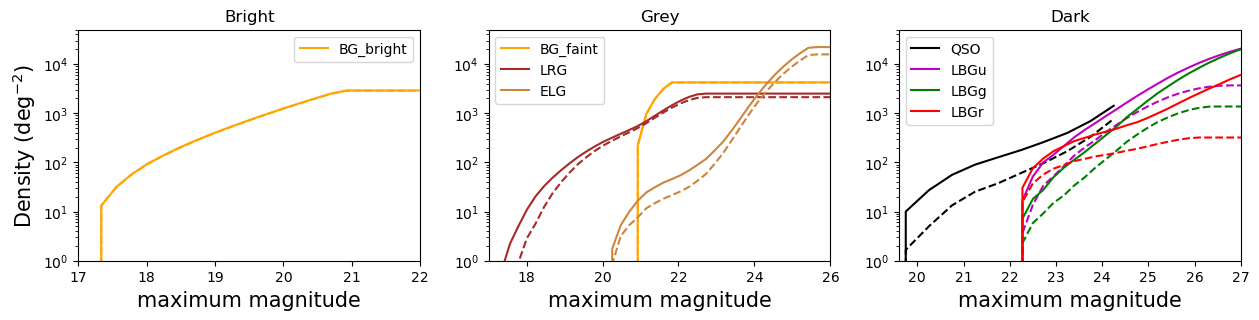

In [5]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    for j, tracer in enumerate(config['tracers']):
        plt.plot( config[tracer + '_' + 'mag_centers'], config[tracer + '_' + 'target_density'], f'-', color = config['color'][j], label = tracer)
        plt.plot( config[tracer + '_' + 'mag_centers'], config[tracer + '_' + 'spec_density'], f'--', color = config['color'][j])

    if i==0: 
        plt.ylabel(r'Density (deg$^{-2}$)', fontsize=15)
        plt.xlim(17, 22)
    plt.ylim(1, 5e4)
    if i==1:
        plt.xlim(17, 26)
        plt.ylim(1, 5e4)

    if i==2:
        plt.xlim(19.6, 27)
        plt.ylim(1, 5e4)

    plt.legend()
    plt.xlabel('maximum magnitude', fontsize=15)
        
        
    plt.yscale('log')
#plt.savefig(f'../figures/total_density.png', dpi = 300, bbox_inches='tight' )

/tmp/ipykernel_1297746/980643374.py:8: RuntimeWarning: invalid value encountered in divide
  config[tracer + '_' + 'spec_density']/config[tracer + '_' + 'target_density'], f'', color = config['color'][j], label = tracer)


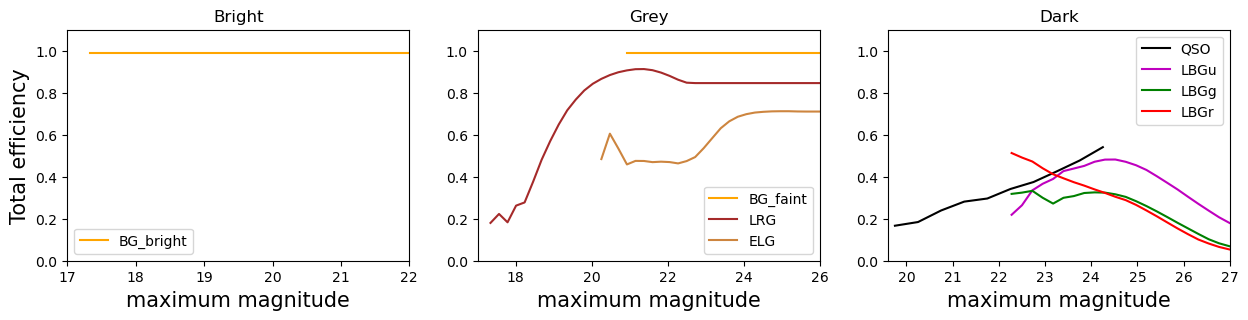

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    for j, tracer in enumerate(config['tracers']):
        plt.plot( config[tracer + '_' + 'mag_centers'], 
                 config[tracer + '_' + 'spec_density']/config[tracer + '_' + 'target_density'], f'', color = config['color'][j], label = tracer)


    if i==0: 
        plt.ylabel('Total efficiency', fontsize=15)
        plt.xlim(17, 22)
    plt.ylim(0,1.1)
    if i==1:
        plt.xlim(17, 26)


    if i==2:
        plt.xlim(19.6, 27)


    plt.legend()
    plt.xlabel('maximum magnitude', fontsize=15)
plt.savefig(f'../figures/total_efficiency.png', dpi = 300, bbox_inches='tight' )
        

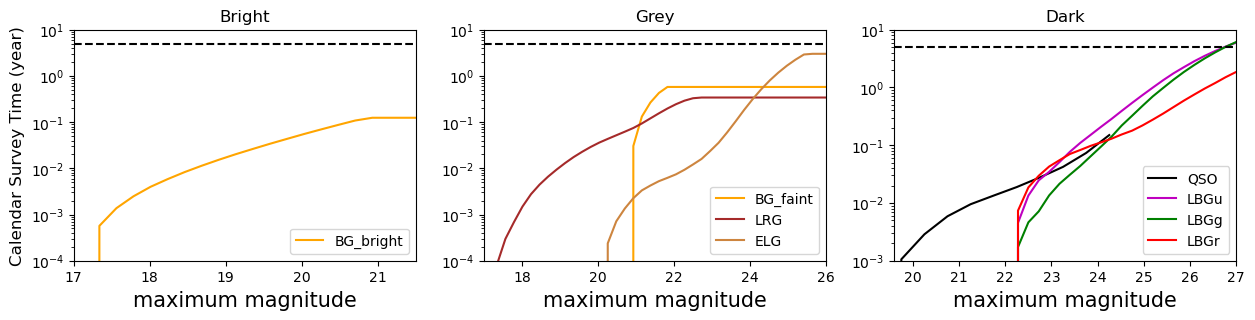

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15, 3))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    for j, tracer in enumerate(config['tracers']):
        plt.plot( config[tracer + '_' + 'mag_centers'], config[tracer + '_' + 'calendar_time'], f'-', color = config['color'][j], label = tracer)
    plt.axhline(5, color='k', ls='--')


    if i==0: 
        plt.ylabel('Calendar Survey Time (year)', fontsize=12)
        plt.xlim(17, 21.5)
        plt.ylim(0.0001, 10)
    
    if i==1:
        plt.xlim(17, 26)
        plt.ylim(0.0001, 10)
    #    plt.ylim(1, 5e4)

    if i==2:
        plt.ylim(0.001, 10)
        plt.xlim(19.6, 27)
    #    plt.ylim(1, 5e4)

    plt.legend()
    plt.xlabel('maximum magnitude', fontsize=15)
        
        
    plt.yscale('log')
#plt.savefig(f'../figures/total_survey_time.png', dpi = 300, bbox_inches='tight' )

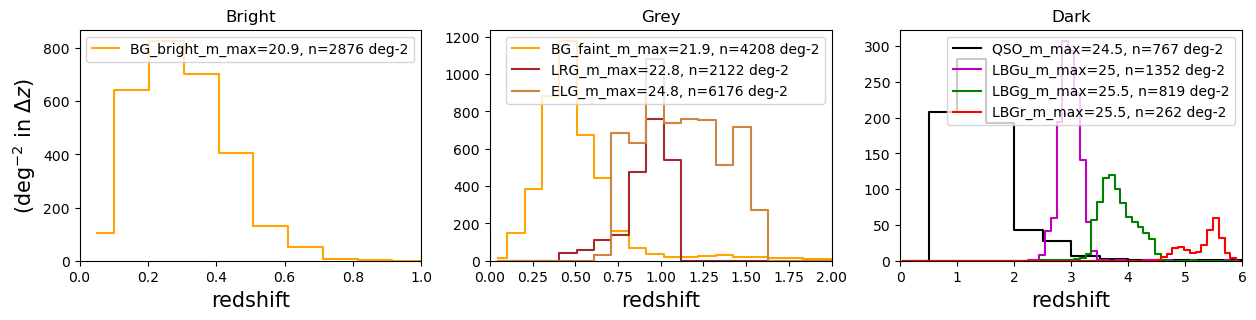

In [8]:
import matplotlib.pyplot as plt
mag_max = [[20.9], [21.9, 22.8, 24.8], [24.5, 25, 25.5, 25.5]]
plt.figure(figsize=(15, 3))
for i, config in enumerate([config_bright_update, config_grey_update, config_dark_update]):
    plt.subplot(131+i)
    plt.title(config['survey_type'])
    
    for j, tracer in enumerate(config['tracers']):
        index = np.argmin(abs(config[tracer + '_' + 'mag_centers'] - mag_max[i][j]))

        n = config[tracer + '_' + 'spec_density'][index]

        z, x = config[tracer + '_' + 'redshift_centers'], config[tracer + '_' + 'spec_redshift_density'][index]
        x = x
        plt.step(z ,x, 
                 f'-',  color = config['color'][j], where='mid', label = tracer + f'_m_max={mag_max[i][j]}, n={n:.0f} deg-2')

        z, x = config[tracer + '_' + 'redshift_centers'], config[tracer + '_' + 'target_redshift_density'][index]
        x = x
       # plt.step(z ,x, 
       #          f'--',  color = config['color'][j], where='mid')
    if i==0:
        plt.xlim(0,1)
        plt.ylabel(r'(deg$^{-2}$ in $\Delta z$)', fontsize=15)


    plt.legend()
    if i==1: plt.xlim(0, 2)
    if i==2: plt.xlim(0, 6)
    #plt.ylim(0, 1500)
    plt.ylim(0)
    
    plt.xlabel('redshift', fontsize=15)

#plt.savefig(f'../figures/total_redshift_density.png', dpi = 300, bbox_inches='tight' )